## RFM ANALYSIS

In [31]:
import pandas as pd

df = pd.read_csv("data/transactions.csv")
df.head()

# Clean data and remove missing values
df = df.dropna()  # Remove rows with any missing values

df.to_csv("data/transactions_clean.csv", index=False)

print("Cleaned CSV saved successfully!")

Cleaned CSV saved successfully!


In [32]:
if 'df' not in globals():
    import pandas as pd
    df = pd.read_csv("data/transactions_clean.csv")

print(df.describe())
print(df.isna().sum())

           Quantity         Price   Customer ID        Amount
count  37498.000000  37498.000000  37498.000000  37498.000000
mean      14.210011      3.436363  15265.053576     22.908083
std      385.984433     45.257268   1714.819715    407.577730
min     -240.000000      0.000000  12346.000000  -1642.500000
25%        2.000000      1.250000  13890.000000      4.200000
50%        5.000000      1.950000  15106.000000     10.500000
75%       12.000000      3.750000  16770.000000     19.500000
max    74215.000000   8142.750000  18287.000000  77183.600000
Invoice        0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Amount         0
dtype: int64


In [33]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [34]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [35]:
# compute RFM metrics
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'count',
    'Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,1,77183.60
12347.0,2,16,302.60
12348.0,249,4,423.52
12349.0,19,6,150.45
12350.0,310,2,42.90


In [36]:
rfm_clean = rfm[rfm['Monetary'] < rfm['Monetary'].quantile(0.99)].copy()

# DATA PREPROCESSING

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean)


# Elbow Method to find no. of cluster 

In [38]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

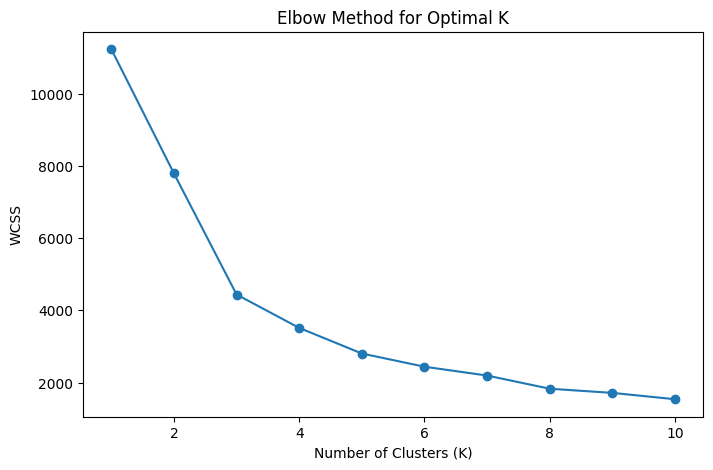

In [39]:
plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

# K-means clustering

In [40]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm_clean['Cluster'] = kmeans.fit_predict(rfm_scaled)

# visualization

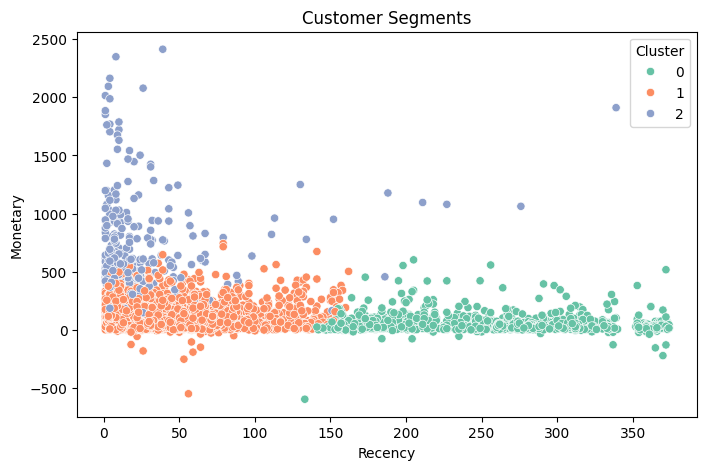

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(data=rfm_clean, x='Recency', y='Monetary', hue='Cluster', palette='Set2')
plt.title("Customer Segments")
plt.show()

In [42]:
rfm_clean.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,248.301619,3.273279,54.908330
1,47.359477,7.606618,113.627978
2,23.526144,38.215686,703.007157


## Customer Segmentation Insights (Final Clusters)

The clustering analysis identified three distinct customer segments based on RFM (Recency, Frequency, Monetary) metrics:

- **Cluster 2** represents high-value customers, characterized by low recency (23 days), very high purchase frequency (~38 transactions), and the highest monetary contribution (~703). These customers are highly engaged and contribute significantly to overall revenue.

- **Cluster 1** consists of moderate-value customers, with moderate recency (~47 days), moderate purchase frequency (~7.6), and moderate spending (~113). These customers are relatively active but have the potential to increase their engagement and value.

- **Cluster 0** represents low-value or churn-risk customers, characterized by very high recency (~248 days), low purchase frequency (~3.2), and low spending (~54). These customers are largely inactive and at risk of being lost.

Overall, the segmentation clearly differentiates between high-value, mid-tier, and low-engagement customers. These insights enable businesses to implement targeted strategies such as retention programs for high-value customers, upselling for moderate customers, and reactivation campaigns for churn-risk customers.